# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [11]:
import pandas as pd

df = pd.read_csv('Mcdonalds_Reviews.csv', encoding='latin-1')

df.head()

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


Positive Review Titles


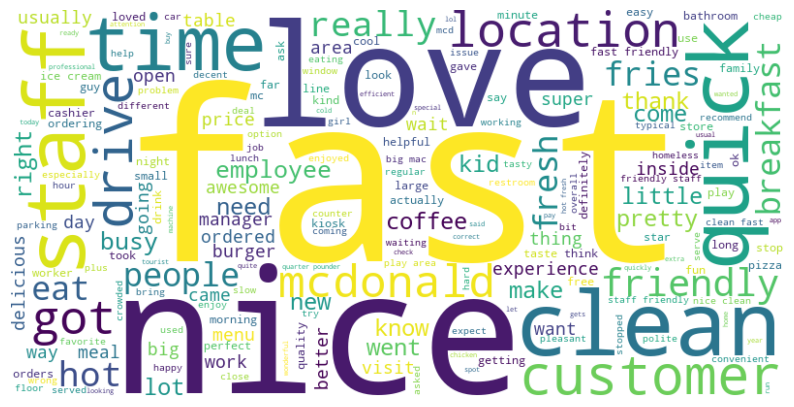

Negative Review Titles


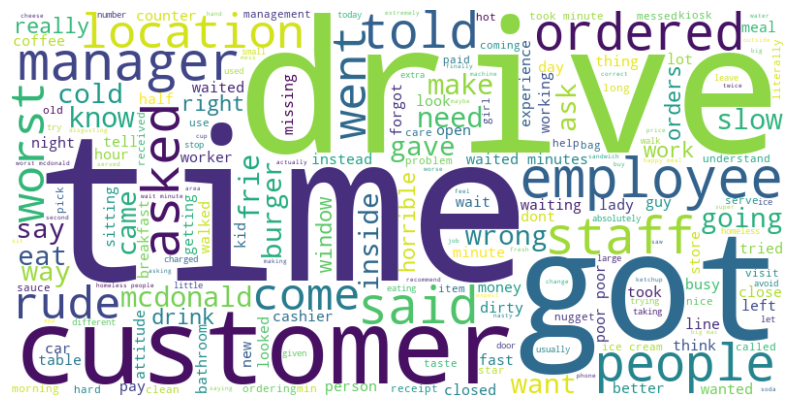

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

# Define additional stopwords to remove
additional_stopwords = {'food', 'restaurant', 'good', 'great', 'best', 'excellent', 'amazing', 'bad', 'terrible', 'place', 'order', 'service'}

# Separate positive and negative reviews using the correct column name
# the dataset has a column named "review", not "Review Title"
positive_reviews = ' '.join(df[df['rating'].isin(['4 stars', '5 stars'])]['review'].astype(str))
negative_reviews = ' '.join(df[df['rating'].isin(['2 stars', '1 star'])]['review'].astype(str))

postive_words = positive_reviews.lower().split()
    
postive_words = [word.strip(string.punctuation) for word in postive_words if word.isalnum() and word not in sklearn_stop_words and word not in additional_stopwords]
    
print('Positive Review Titles')
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(postive_words))
plt.figure(figsize=(10, 7)) 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

negative_words = negative_reviews.lower().split()
    
negative_words = [word.strip(string.punctuation) for word in negative_words if word.isalnum() and word not in sklearn_stop_words and word not in additional_stopwords]
    
print('Negative Review Titles')
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(negative_words))
plt.figure(figsize=(10, 7)) 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Word clouds

Pictured above are word clouds, these are really neat ways to display some of the most commonly found words across reviews. These are great for glancing at and seeing common phrases, perhaps for a presentation or marketing piece.

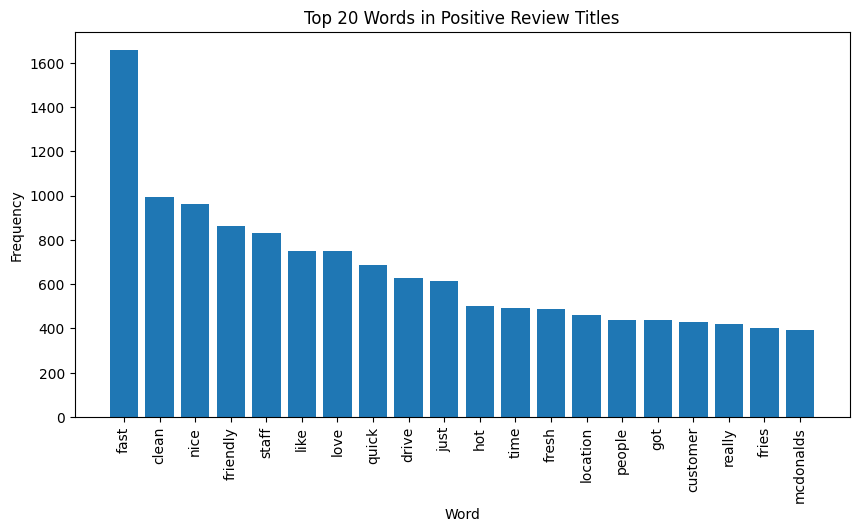

In [13]:
positive_word_freq = Counter(postive_words)
positive_common_words = positive_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
positive_freq_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(positive_freq_df['Word'], positive_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Positive Review Titles')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

# Word frequencies

Here we have the most commonly found words in reviews. As you can see, fast and clean are at the top, which is great! This could be used to quickly and easily take notes on where to improve, or see what a business is doing right.

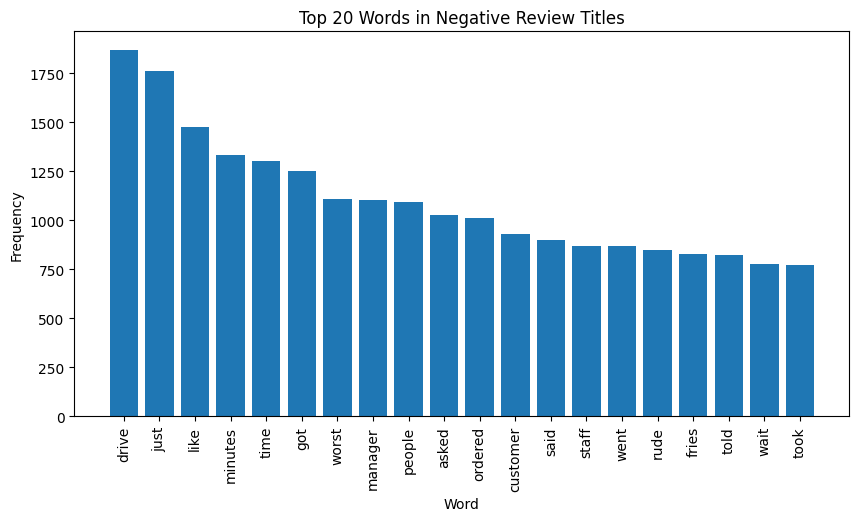

In [14]:
negative_word_freq = Counter(negative_words)
negative_common_words = negative_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
negative_freq_df = pd.DataFrame(negative_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(negative_freq_df['Word'], negative_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Negative Review Titles')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

In [15]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from textblob import TextBlob
import plotly.express as px

# Sentiment calculations
df['calc_sentiment'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['abs_sentiment'] = df['calc_sentiment'].abs()

# Optional: Make sentiment a category to suppress warning
df['rating'] = df['rating'].astype(str)

# Plot
fig = px.scatter(
    df, 
    x='calc_sentiment', 
    y='subjectivity', 
    hover_data=['review'],
    color='rating',
    size='abs_sentiment',
    size_max=15,
    title='Sentiment Polarity vs Subjectivity',
    hover_name='store_name',
    labels={'sentiment': 'Sentiment Polarity', 'subjectivity': 'Subjectivity'}
)

fig.update_layout(xaxis_title='Sentiment', height=500)
fig.show()

# Sentiment TextBlob

Here is my favorite visual out of all that we have learned, the Sentiment vs Subjectivity chart. The visible split between positive and negative ratings easily shows off the distribution and allows you to see where the groupings lie.